In [2]:
import pandas as pd

# 读取原始完整数据集 UserBehavior.csv
df_all = pd.read_csv("UserBehavior.csv",names=["user_id","item_id","category_id","behavior_type","timestamp"])

# 随机抽样100000条，random_state固定种子，保证复现
df_sample = df_all.sample(n=100000, random_state=66)

# 去重：去除完全重复行为记录
df_sample = df_sample.drop_duplicates(subset=["user_id","item_id","behavior_type","timestamp"])

# 只输出5个原始字段
df_sample.to_csv("sample_random_10w.csv",index=False,header=False)

print(f"抽样后记录行数：{len(df_sample)}")
print(f"抽样后独立用户数：{df_sample['user_id'].nunique()}")

抽样后记录行数：100000
抽样后独立用户数：91952


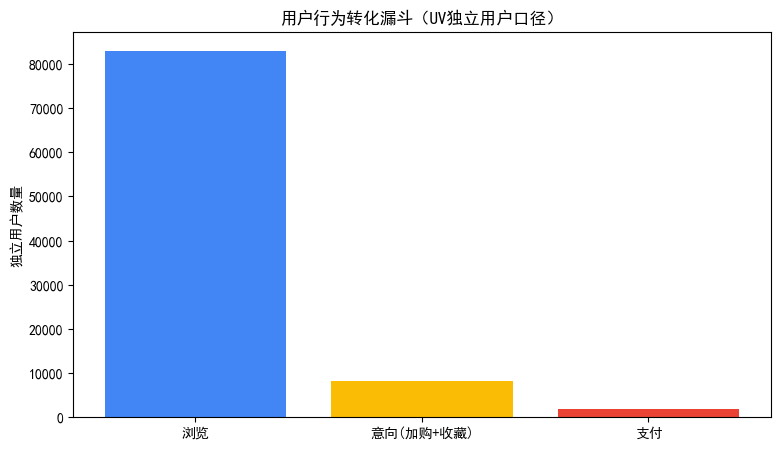

浏览→意向转化率：9.90%
意向→支付转化率：23.90%
浏览→整体支付转化率：2.37%


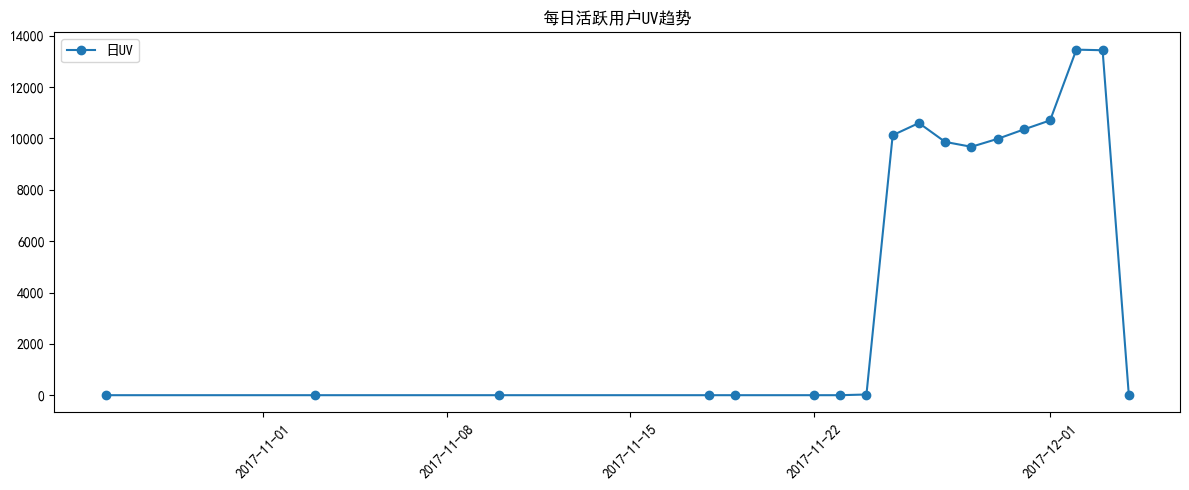

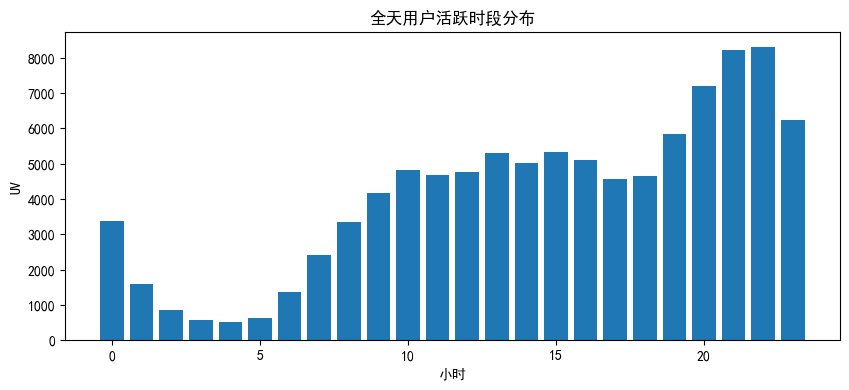


总支付用户：1965 | 复购用户：6 | 用户复购率：0.31%


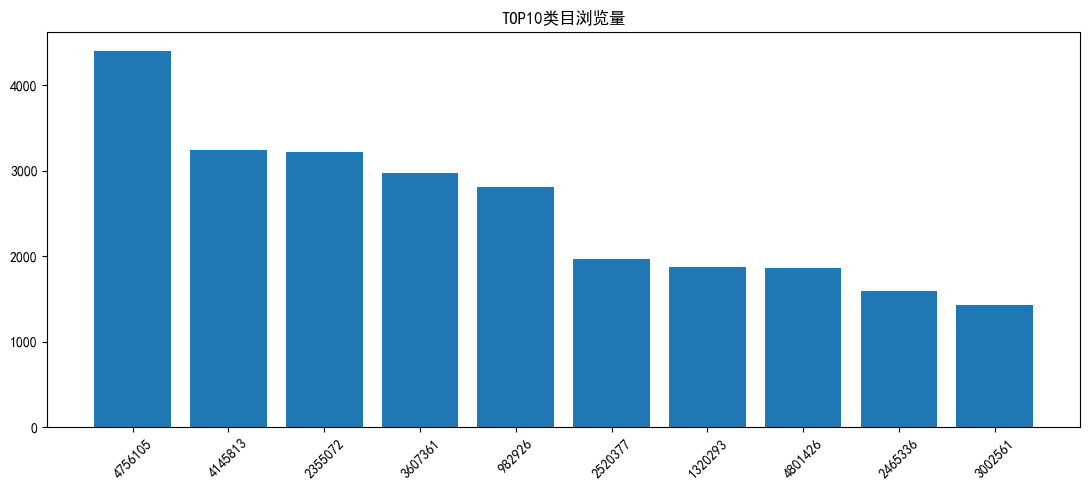


数据集时间区间：2017-10-26 ~ 2017-12-04
总用户数：91949
用户平均活跃天数：1.2 天

用户活跃度分层统计：
user_tag
一次性用户（仅活跃1天）    86003
中活用户（3‑6天）       3437
低活用户（2天）         1405
高活用户（7天及以上）      1104
Name: count, dtype: int64


D:\spark\python3.10.2\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


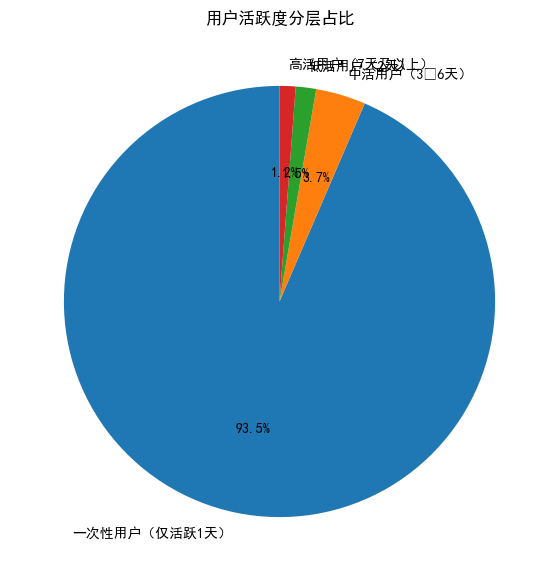

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

view_uv = 83030
intend_uv = 8223
pay_uv = 1965

# 1、转化漏斗
funnel = pd.DataFrame({
    "stage":["浏览","意向(加购+收藏)","支付"],
    "user_cnt":[view_uv, intend_uv, pay_uv]
})
plt.figure(figsize=(9,5))
plt.bar(funnel["stage"],funnel["user_cnt"],color=["#4285F4","#FBBC05","#EA4335"])
plt.title("用户行为转化漏斗（UV独立用户口径）")
plt.ylabel("独立用户数量")
plt.show()

view2intend = intend_uv / view_uv
intend2pay = pay_uv / intend_uv
view2pay = pay_uv / view_uv
print(f"浏览→意向转化率：{view2intend:.2%}")
print(f"意向→支付转化率：{intend2pay:.2%}")
print(f"浏览→整体支付转化率：{view2pay:.2%}")

# 2、每日UV趋势
df_day = pd.read_csv("day_pv_uv.csv")
df_day["dt"] = pd.to_datetime(df_day["dt"], errors="coerce")
df_day = df_day[df_day["dt"].dt.year == 2017].copy()
plt.figure(figsize=(12,5))
plt.plot(df_day["dt"], df_day["uv"], marker="o", label="日UV")
plt.title("每日活跃用户UV趋势")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 3、小时活跃度分布
df_hour = pd.read_csv("hour_uv.csv")
plt.figure(figsize=(10,4))
plt.bar(df_hour["hour"], df_hour["uv"])
plt.title("全天用户活跃时段分布")
plt.xlabel("小时")
plt.ylabel("UV")
plt.show()

# 4、复购率
df_pay = pd.read_csv("user_pay_cnt.csv")
total_pay_user = len(df_pay)
repeat_user = len(df_pay[df_pay["pay_count"]>=2])
repeat_rate = repeat_user / total_pay_user
print(f"\n总支付用户：{total_pay_user} | 复购用户：{repeat_user} | 用户复购率：{repeat_rate:.2%}")

# 5、TOP10类目浏览量
df_cat = pd.read_csv("top_category.csv")
plt.figure(figsize=(11,5))
plt.bar(df_cat["category_id"].astype(str), df_cat["pv"])
plt.title("TOP10类目浏览量")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6、用户活跃度分层（随机抽样后，会出现一次性、低活用户）
df_user_range = pd.read_csv("user_active_range.csv")
df_user_range["first_date"] = pd.to_datetime(df_user_range["first_date"])
df_user_range["last_date"] = pd.to_datetime(df_user_range["last_date"])

df_user_range = df_user_range[(df_user_range["first_date"].dt.year == 2017) &(df_user_range["last_date"].dt.year == 2017)].copy()

df_user_range["active_days"] = (df_user_range["last_date"] - df_user_range["first_date"]).dt.days + 1

print(f"\n数据集时间区间：{df_user_range['first_date'].min().date()} ~ {df_user_range['last_date'].max().date()}")
print(f"总用户数：{len(df_user_range)}")
print(f"用户平均活跃天数：{df_user_range['active_days'].mean():.1f} 天")

def user_type(days):
    if days >= 7:
        return "高活用户（7天及以上）"
    elif days >= 3:
        return "中活用户（3‑6天）"
    elif days >= 2:
        return "低活用户（2天）"
    else:
        return "一次性用户（仅活跃1天）"

df_user_range["user_tag"] = df_user_range["active_days"].apply(user_type)
print("\n用户活跃度分层统计：")
print(df_user_range["user_tag"].value_counts())

plt.figure(figsize=(7,7))
df_user_range["user_tag"].value_counts().plot.pie(autopct="%.1f%%", startangle=90)
plt.title("用户活跃度分层占比")
plt.ylabel("")
plt.show()